# Explore the practice dataset

Shrestha et al. (2024): maize hybrid trials at five US Corn Belt sites in 2022, with six Pléiades Neo satellite images per plot. This notebook reads the **canonical** tables (`python -m soilsignal_ml ingest`), the same ones training uses. Run it from `ml/` with `uv run --project ../backend --group ml jupyter ...`, or execute it headless with nbclient.

In [1]:
import soilsignal_ml  # puts backend/ on the import path
import matplotlib.pyplot as plt
import pandas as pd
from soilsignal_ml.ingest.canonical import CanonicalDataset

ds = CanonicalDataset.load('shrestha2024')
{t: getattr(ds, t).shape for t in ('plots', 'observations', 'weather', 'soil', 'county_yields', 'sites')}

{'plots': (2275, 17),
 'observations': (13650, 15),
 'weather': (1225, 8),
 'soil': (2275, 12),
 'county_yields': (58, 3),
 'sites': (5, 11)}

## Yield by site

Between-site differences dwarf within-site ones. Lincoln was rainfed through the 2022 drought; Scottsbluff is irrigated.

In [2]:
ds.plots.groupby('site_id')['final_yield'].describe().round(1)

,count,mean,std,min,25%,50%,75%,max
site_id,,,,,,,,
Ames,487.0,130.3,31.8,27.3,111.8,131.5,151.8,221.5
Crawfordsville,488.0,165.1,24.7,69.5,149.5,166.2,179.4,243.9
Lincoln,504.0,41.2,24.9,1.7,21.4,38.2,57.4,144.9
MOValley,163.0,152.5,24.3,89.6,135.9,154.7,168.0,214.1
Scottsbluff,489.0,143.4,34.2,49.7,119.9,145.0,166.4,229.2


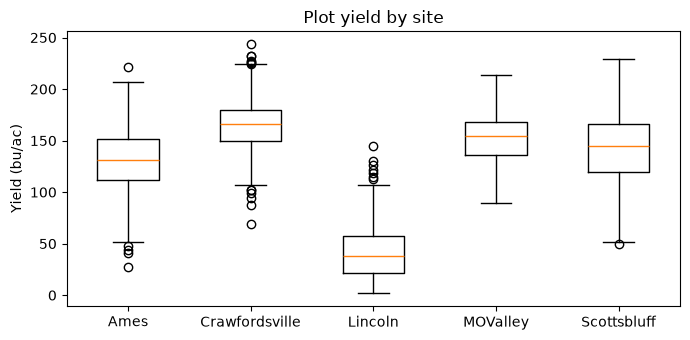

In [3]:
fig, ax = plt.subplots(figsize=(7, 3.5))
sites = sorted(ds.plots['site_id'].unique())
ax.boxplot([ds.plots.loc[ds.plots.site_id == s, 'final_yield'].dropna() for s in sites], tick_labels=sites)
ax.set_ylabel('Yield (bu/ac)'); ax.set_title('Plot yield by site'); plt.tight_layout()

## Canopy through the season

Median NDVI per image. Lincoln's canopy collapses in August (drought); the Iowa sites senesce in September; Scottsbluff starts late.

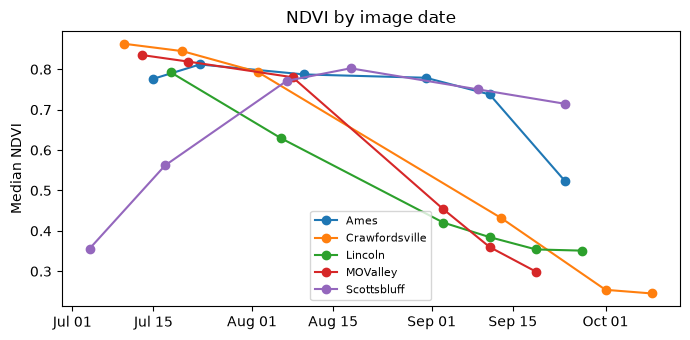

In [4]:
obs = ds.observations.merge(ds.plots[['plot_id', 'site_id']], on='plot_id')
obs['date'] = pd.to_datetime(obs['date'])
fig, ax = plt.subplots(figsize=(7, 3.5))
for site, g in obs.groupby('site_id'):
    m = g.groupby('date')['ndvi'].median()
    ax.plot(m.index, m.values, marker='o', label=site)
import matplotlib.dates as mdates
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %d'))
ax.set_ylabel('Median NDVI'); ax.legend(fontsize=8); ax.set_title('NDVI by image date'); plt.tight_layout()

## Does canopy signal track yield?

Within each site, correlation between an image's NDVI and final yield. Early images correlate positively everywhere except Scottsbluff; at Lincoln, plots that stayed green late yielded *less* (plausibly barren, drought-stressed plants).

In [5]:
y = obs.merge(ds.plots[['plot_id', 'final_yield']], on='plot_id').dropna(subset=['final_yield'])
y.groupby(['site_id', 'time_point']).apply(lambda g: g['ndvi'].corr(g['final_yield'])).unstack().round(2)

time_point,1,2,3,4,5,6
site_id,,,,,,
Ames,0.06,0.31,0.57,0.57,0.36,0.16
Crawfordsville,0.30,0.33,0.40,0.31,0.12,-0.11
Lincoln,0.47,0.57,-0.33,-0.47,-0.52,-0.52
MOValley,0.31,0.44,0.65,0.46,0.33,0.11
Scottsbluff,-0.13,-0.03,-0.08,-0.12,-0.16,-0.21


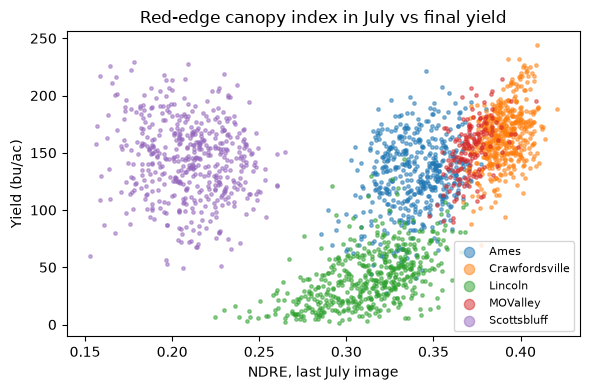

In [6]:
july = y[y['date'].dt.month == 7].sort_values('date').groupby('plot_id').last()
fig, ax = plt.subplots(figsize=(6, 4))
for site, g in july.groupby('site_id'):
    ax.scatter(g['ndre'], g['final_yield'], s=6, alpha=0.5, label=site)
ax.set_xlabel('NDRE, last July image'); ax.set_ylabel('Yield (bu/ac)'); ax.legend(fontsize=8, markerscale=3)
ax.set_title('Red-edge canopy index in July vs final yield'); plt.tight_layout()

## Weather from planting (NOAA GHCN-Daily, gap-filled from nearby stations)

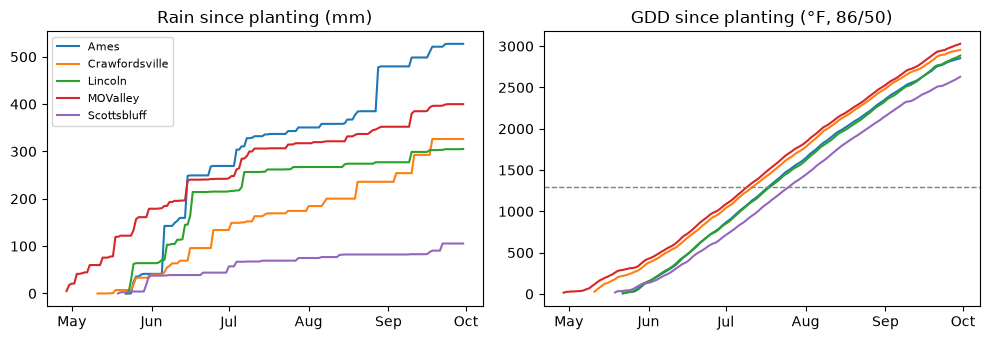

In [7]:
from app.features.weather import modified_gdd
w = ds.weather.copy(); w['date'] = pd.to_datetime(w['date'])
fig, axes = plt.subplots(1, 2, figsize=(10, 3.5))
for site, g in w.groupby('site_id'):
    planting = pd.Timestamp(ds.plots.loc[ds.plots.site_id == site, 'planting_date'].min())
    g = g[(g['date'] >= planting) & (g['date'] <= '2022-09-30')].sort_values('date')
    axes[0].plot(g['date'], g['prcp_mm'].fillna(0).cumsum(), label=site)
    gdd = [modified_gdd(a, b) if pd.notna(a) and pd.notna(b) else 0 for a, b in zip(g['tmax_f'], g['tmin_f'])]
    axes[1].plot(g['date'], pd.Series(gdd).cumsum().values, label=site)
axes[0].set_title('Rain since planting (mm)'); axes[1].set_title('GDD since planting (°F, 86/50)')
import matplotlib.dates as mdates
for a in axes: a.xaxis.set_major_formatter(mdates.DateFormatter('%b'))
axes[1].axhline(1300, ls='--', c='grey', lw=1); axes[0].legend(fontsize=8); plt.tight_layout()

## Nitrogen rate

Mean yield by N rate. In this trial design each N rate is largely its own experiment block, so N is partly confounded with field position, which the model report flags.

In [8]:
ds.plots.pivot_table(index='site_id', columns='nitrogen_lb_ac', values='final_yield', aggfunc='mean').round(1)

nitrogen_lb_ac,75.0,150.0,175.0,225.0,250.0
site_id,,,,,
Ames,145.2,122.1,NaN,NaN,123.6
Crawfordsville,158.7,174.3,NaN,162.2,NaN
Lincoln,43.0,53.2,NaN,27.5,NaN
MOValley,NaN,NaN,152.5,NaN,NaN
Scottsbluff,120.1,149.2,NaN,161.5,NaN


## Features as the July 31 model sees them

Built by the backend's `build_features()`, the function the API also calls. Only images and weather up to July 31 are visible.

In [9]:
from soilsignal_ml.features.build import feature_table
table = feature_table(ds, '07-31')
missing = table.drop(columns=['plot_id', 'field_id', 'site_id', 'year', 'final_yield']).isna().groupby(table['site_id']).mean()
print(table.shape)
missing.loc[:, missing.max() > 0].round(2).T.head(15)

(2131, 91)


site_id,Ames,Crawfordsville,Lincoln,MOValley,Scottsbluff
county_yield_prev_year,0.0,1.0,0.0,1.0,0.0
ndvi_change_from_previous,0.0,0.0,1.0,0.0,0.0
ndvi_trend_per_10d,0.0,0.0,1.0,0.0,0.0
ndvi_area_to_date,0.0,0.0,1.0,0.0,0.0
ndre_change_from_previous,0.0,0.0,1.0,0.0,0.0
ndre_trend_per_10d,0.0,0.0,1.0,0.0,0.0
ndre_area_to_date,0.0,0.0,1.0,0.0,0.0
gndvi_change_from_previous,0.0,0.0,1.0,0.0,0.0
gndvi_trend_per_10d,0.0,0.0,1.0,0.0,0.0
gndvi_area_to_date,0.0,0.0,1.0,0.0,0.0
